In [1]:
import os
import joblib
import pandas as pd
import itertools
import scanpy as sc
os.listdir("../Store")
cut_off = 1000

In [2]:
from collections import defaultdict

def addGeneClusters(geneDict, clusters):
    clusters = invertDict(clusters)
    resultValues = list(geneDict.values())
    resultKeys = list(geneDict.keys())

    for gene, cluster in clusters.items():
        if gene in list(geneDict.keys()):
            insertGenes = list(set(cluster) - set([gene]))
            idx = resultKeys.index(gene)
            resultValues[idx+1:idx+1] = [resultValues[idx]] * len(insertGenes)
            resultKeys[idx+1:idx+1] = insertGenes

    return dict(zip(resultKeys, resultValues))

def invertDict(d):
    inverted = defaultdict(list)

    for keys_tuple, value in d.items():
        inverted[value].extend(list(keys_tuple))

    return dict(inverted)


def filter_zero_gene(geneDict):
    return {k: v for k,v in geneDict.items() if v>0}


def filter_pval(dea_dict):
    return {k: v for k,v in dea_dict.items() if v<=0.05}




        
def check_lit(dea_genes, enriched_genes):
    limit = None  # Or an integer value if truncation is desired

    genes_of_interest = [
        "GABPA", "CTCF", "EGR1", "YY1", "SPI1", "CLOCK", "ARNTL", "BACH1",
        "GFI1", "IFNB1", "MOG", "MBP", "CD42", "IFNG", "IL17A", "IL10",
        "TNF", "IL1B", "IL6", "TNFRSF1A", "CYP27B1", "IL7R", "HLA-DRB1",
        "HLA-DRB5", "IL2RA"
    ]

    # Store the dictionary views for efficient 'in' checks
    enriched_genes = enriched_genes.keys()
    dea_genes_keys = dea_genes.keys()

    for gene in genes_of_interest:
        in_enriched = gene in list(enriched_genes)[:limit] if limit else gene in enriched_genes
        in_dea = gene in list(dea_genes_keys)[:limit] if limit else gene in dea_genes_keys

        if in_enriched and in_dea:
            print(gene, "Both")
        elif in_enriched:
            print(gene, "SHAP")
        elif in_dea:
            print(gene, "DEA")
        else:
            print(gene, "None")
            
            
def count_common_genes(enriched_genes, dea_genes):
    """
    Counts the number of common genes between two dictionaries (or dict-like objects)
    where keys represent gene names.

    Args:
        enriched_genes (dict): A dictionary where keys are gene names.
        dea_genes (dict): A dictionary where keys are gene names.

    Returns:
        int: The number of genes common to both inputs.
    """
    # Get the set of keys from both dictionaries for efficient intersection
    set_enriched = set(enriched_genes.keys())
    set_dea = set(dea_genes.keys())

    # Find the intersection of the two sets
    common_genes = set_enriched.intersection(set_dea)

    return len(common_genes)

In [3]:
# CD4 CSF
cd4_csf_dir = "../Store/CD4_CSF_SAMU"
expl_cd4_csf = joblib.load(f'{cd4_csf_dir}/xgbCSFBCELLS_feature_importance.pkl')
expl_cd4_csf = expl_cd4_csf.set_index('Feature')['MeanAbsoluteShap'].to_dict()
print("Pre-zero-filter: ", len(expl_cd4_csf))
expl_cd4_csf = filter_zero_gene(expl_cd4_csf)
print("Post-zero-filter: ", len(expl_cd4_csf))

cd4_full_gene_list = sc.read_h5ad(f'{cd4_csf_dir}/datasetDeclustered.h5ad')
cd4_full_gene_list = cd4_full_gene_list.var_names

#cut off pre cluster per le analisi
expl_cd4_csf_cutoff = dict(itertools.islice(expl_cd4_csf.items(), cut_off))


clusters = joblib.load(f'{cd4_csf_dir}/uniqueClusters.pkl')

expl_cluster_cd4_csf = addGeneClusters(expl_cd4_csf, clusters)
expl_cluster_cd4_csf_cutoff = addGeneClusters(expl_cd4_csf_cutoff, clusters)

dea_cd4_csf = pd.read_csv("../Store/DEA/CSF_CD4.csv")
dea_cd4_csf = dea_cd4_csf.set_index('Unnamed: 0')['p_val_adj'].to_dict()
dea_cd4_csf = filter_pval(dea_cd4_csf)
print("DEA Genes:", len(dea_cd4_csf))

print("No Cluster: ", len(expl_cd4_csf))
print("Cluster: ", len(expl_cluster_cd4_csf))


print("No Cluster cutoff: ", len(expl_cd4_csf_cutoff))
print("Cluster cutoff: ", len(expl_cluster_cd4_csf_cutoff))



print("Literature check")
check_lit(dea_cd4_csf,expl_cluster_cd4_csf_cutoff)

print("Common shap dea")
count_common_genes(expl_cluster_cd4_csf_cutoff, dea_cd4_csf)

Pre-zero-filter:  17236
Post-zero-filter:  13117
DEA Genes: 1018
No Cluster:  13117
Cluster:  13701
No Cluster cutoff:  1000
Cluster cutoff:  1277
Literature check
GABPA None
CTCF None
EGR1 Both
YY1 None
SPI1 DEA
CLOCK None
ARNTL None
BACH1 None
GFI1 None
IFNB1 None
MOG DEA
MBP None
CD42 None
IFNG None
IL17A None
IL10 None
TNF None
IL1B None
IL6 DEA
TNFRSF1A None
CYP27B1 DEA
IL7R None
HLA-DRB1 DEA
HLA-DRB5 None
IL2RA None
Common shap dea


145

In [4]:
# BCELLS PBMC
pbmc_bcells_dir = "../Store/PBMC_BCELLS_2DATASET"
expl_bcells_pbmc = joblib.load(f'{pbmc_bcells_dir}/xgbPBMCBCELLS_feature_importance.pkl')
expl_bcells_pbmc = expl_bcells_pbmc.set_index('Feature')['MeanAbsoluteShap'].to_dict()
print("Pre-zero-filter: ", len(expl_bcells_pbmc))
expl_bcells_pbmc = filter_zero_gene(expl_bcells_pbmc)
print("Post-zero-filter: ", len(expl_bcells_pbmc))

#cut off pre cluster per le analisi
expl_bcells_pbmc_cutoff = dict(itertools.islice(expl_bcells_pbmc.items(), cut_off))


clusters = joblib.load(f'{pbmc_bcells_dir}/uniqueClusters.pkl')

expl_cluster_bcells_pbmc = addGeneClusters(expl_bcells_pbmc, clusters)
expl_cluster_bcells_pbmc_cutoff = addGeneClusters(expl_bcells_pbmc_cutoff, clusters)


bcells_pbmc_full_gene_list = sc.read_h5ad(f'{pbmc_bcells_dir}/datasetDeclustered.h5ad')
bcells_pbmc_full_gene_list = bcells_pbmc_full_gene_list.var_names


dea_bcells_pbmc = pd.read_csv("../Store/DEA/PBMC_BCELLS.csv")
dea_bcells_pbmc = dea_bcells_pbmc.set_index('Unnamed: 0')['p_val_adj'].to_dict()
dea_bcells_pbmc = filter_pval(dea_bcells_pbmc)
print("DEA Genes:", len(dea_bcells_pbmc))


print("No Cluster: ", len(expl_bcells_pbmc))
print("Cluster: ", len(expl_cluster_bcells_pbmc))


print("No Cluster cutoff: ", len(expl_bcells_pbmc_cutoff))
print("Cluster cutoff: ", len(expl_cluster_bcells_pbmc_cutoff))

print("Literature check")
check_lit(dea_bcells_pbmc,expl_cluster_bcells_pbmc_cutoff)
print("Common shap dea")
count_common_genes(expl_cluster_bcells_pbmc_cutoff, dea_bcells_pbmc)

Pre-zero-filter:  17410
Post-zero-filter:  96
DEA Genes: 3925
No Cluster:  96
Cluster:  439
No Cluster cutoff:  96
Cluster cutoff:  439
Literature check
GABPA None
CTCF None
EGR1 DEA
YY1 None
SPI1 None
CLOCK None
ARNTL None
BACH1 None
GFI1 None
IFNB1 None
MOG DEA
MBP None
CD42 None
IFNG None
IL17A None
IL10 DEA
TNF DEA
IL1B None
IL6 None
TNFRSF1A None
CYP27B1 None
IL7R DEA
HLA-DRB1 None
HLA-DRB5 None
IL2RA DEA
Common shap dea


287

In [5]:
# BCELLS CSF
csf_bcells_dir = "../Store/CSF_BCELLS"
expl_bcells_csf = joblib.load(f'{csf_bcells_dir}/xgbCSFBCELLS2_feature_importance.pkl')
expl_bcells_csf = expl_bcells_csf.set_index('Feature')['MeanAbsoluteShap'].to_dict()
print("Pre-zero-filter: ", len(expl_bcells_csf))
expl_bcells_csf = filter_zero_gene(expl_bcells_csf)
print("Post-zero-filter: ", len(expl_bcells_csf))


#cut off pre cluster per le analisi
expl_bcells_csf_cutoff = dict(itertools.islice(expl_bcells_csf.items(), cut_off))

bcells_csf_full_gene_list = sc.read_h5ad(f'{csf_bcells_dir}/datasetDeclustered.h5ad')
bcells_csf_full_gene_list = bcells_csf_full_gene_list.var_names


clusters = joblib.load(f'{csf_bcells_dir}/uniqueClusters.pkl')

expl_cluster_bcells_csf = addGeneClusters(expl_bcells_csf, clusters)
expl_cluster_bcells_csf_cutoff = addGeneClusters(expl_bcells_csf_cutoff, clusters)

dea_bcells_csf = pd.read_csv("../Store/DEA/CSF_BCells.csv")
dea_bcells_csf = dea_bcells_csf.set_index('Unnamed: 0')['p_val_adj'].to_dict()
dea_bcells_csf = filter_pval(dea_bcells_csf)
print("DEA Genes:", len(dea_bcells_csf))



print("No Cluster: ", len(expl_bcells_csf))
print("Cluster: ", len(expl_cluster_bcells_csf))


print("No Cluster cutoff: ", len(expl_bcells_csf_cutoff))
print("Cluster cutoff: ", len(expl_cluster_bcells_csf_cutoff))


print("Literature check")
check_lit(dea_bcells_csf,expl_cluster_bcells_csf_cutoff)

print("Common shap dea")
count_common_genes(expl_cluster_bcells_csf_cutoff, dea_bcells_csf)

Pre-zero-filter:  16505
Post-zero-filter:  3073
DEA Genes: 727
No Cluster:  3073
Cluster:  5444
No Cluster cutoff:  1000
Cluster cutoff:  2115
Literature check
GABPA None
CTCF None
EGR1 None
YY1 None
SPI1 None
CLOCK None
ARNTL None
BACH1 None
GFI1 DEA
IFNB1 None
MOG SHAP
MBP None
CD42 None
IFNG DEA
IL17A None
IL10 None
TNF None
IL1B None
IL6 None
TNFRSF1A None
CYP27B1 None
IL7R SHAP
HLA-DRB1 None
HLA-DRB5 SHAP
IL2RA DEA
Common shap dea


166

In [6]:
# MICROARRAY
csf_bcells_dir = "../Store/MICROARRAY"
expl_microarray = joblib.load(f'{csf_bcells_dir}/xgbDefFull_explSorted.pkl')
print("Pre-zero-filter: ", len(expl_microarray))
expl_microarray = filter_zero_gene(expl_microarray)
print("Post-zero-filter: ", len(expl_microarray))

#cut off pre cluster per le analisi
expl_microarray_cutoff = dict(itertools.islice(expl_microarray.items(), cut_off))



clusters = joblib.load(f'{csf_bcells_dir}/uniqueClustersFULL.pkl')

expl_cluster_microarray = addGeneClusters(expl_microarray, clusters)
expl_cluster_microarray_cutoff = addGeneClusters(expl_microarray_cutoff, clusters)

print("No Cluster: ", len(expl_microarray))
print("Cluster: ", len(expl_cluster_microarray))


print("No Cluster cutoff: ", len(expl_microarray_cutoff))
print("Cluster cutoff: ", len(expl_cluster_microarray_cutoff))


Pre-zero-filter:  6668
Post-zero-filter:  724
No Cluster:  724
Cluster:  724
No Cluster cutoff:  724
Cluster cutoff:  724


In [7]:
data_sources = {
    "expl_cluster_cd4_csf_cutoff": expl_cluster_cd4_csf_cutoff,
    "expl_cluster_bcells_pbmc_cutoff": expl_cluster_bcells_pbmc_cutoff,
    "expl_cluster_bcells_csf_cutoff": expl_cluster_bcells_csf_cutoff,
    "expl_cluster_microarray_cutoff": expl_cluster_microarray_cutoff,
}

# Get the total set of genes
total_gene = set().union(
    *[set(d.keys()) for d in data_sources.values()]
)

# Create an empty DataFrame
df = pd.DataFrame(index=list(total_gene))

# Populate the DataFrame
for col_name, data_dict in data_sources.items():
    df[col_name] = df.index.map(lambda gene: data_dict.get(gene, 0))

df.to_csv("csv_cutoff_1000_expl.csv")

In [8]:
from venny4py.venny4py import *
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3 # You might need to import these if not already in your environment

def create_venn_diagram(dict_list, labels, title="Venn Diagram of Gene Sets"):
    """
    Creates a Venn diagram for 2, 3, or 4 sets of gene names.

    Args:
        dict_list (list): A list of dictionaries (e.g., expl_cluster_microarray_cutoff).
                          The keys of these dictionaries are treated as the gene names.
        labels (list): A list of strings for the labels of each set in the Venn diagram.
        title (str): The title of the Venn diagram.
    """
    if not (2 <= len(dict_list) <= 4):
        print("Venn diagrams are supported for 2, 3, or 4 sets only.")
        return

    # Extract gene names as sets from the dictionary keys
    # And create a dictionary where keys are labels and values are the sets
    gene_sets = {label: set(d.keys()) for label, d in zip(labels, dict_list)}

    plt.figure(figsize=(5,5))

    if len(gene_sets) == 2:
        # For venn2 and venn3, you pass the values (the sets) and then the labels separately
        venn2(list(gene_sets.values()), set_labels=list(gene_sets.keys()))
    elif len(gene_sets) == 3:
        venn3(list(gene_sets.values()), set_labels=list(gene_sets.keys()))

        # Calculate and print the intersection for 3 sets
        set1 = list(gene_sets.values())[0]
        set2 = list(gene_sets.values())[1]
        set3 = list(gene_sets.values())[2]

        intersection_genes = set1.intersection(set2, set3)
        print(f"\nGenes in the intersection of all three sets ({', '.join(labels)}):")
        if intersection_genes:
            for gene in sorted(list(intersection_genes)):
                print(f"- {gene}")
        else:
            print("No common genes found in the intersection of all three sets.")
    elif len(gene_sets) == 4:
        venny4py(sets=gene_sets) # venny4py expects a dictionary as 'sets'

    plt.title(title)
    plt.show()
print("\n--- Generating Venn Diagrams ---")
import joblib
import itertools
from matplotlib_venn import venn2, venn3
import matplotlib.pyplot as plt
import pandas as pd # Often useful for inspecting data
# Example 1: Venn Diagram for 2 sets
print("Venn Diagram: Set 1 vs Set 2")
create_venn_diagram(
    [expl_cluster_cd4_csf_cutoff, expl_cluster_bcells_pbmc_cutoff,expl_cluster_bcells_csf_cutoff],
    labels=["cd4csf", "bcellspbmc", "bcellscsf"],
    title="Genes in cd4csf vs bcellspbmc vs bcellscsf",
)

ModuleNotFoundError: No module named 'venny4py'

<Figure size 1000x1000 with 0 Axes>

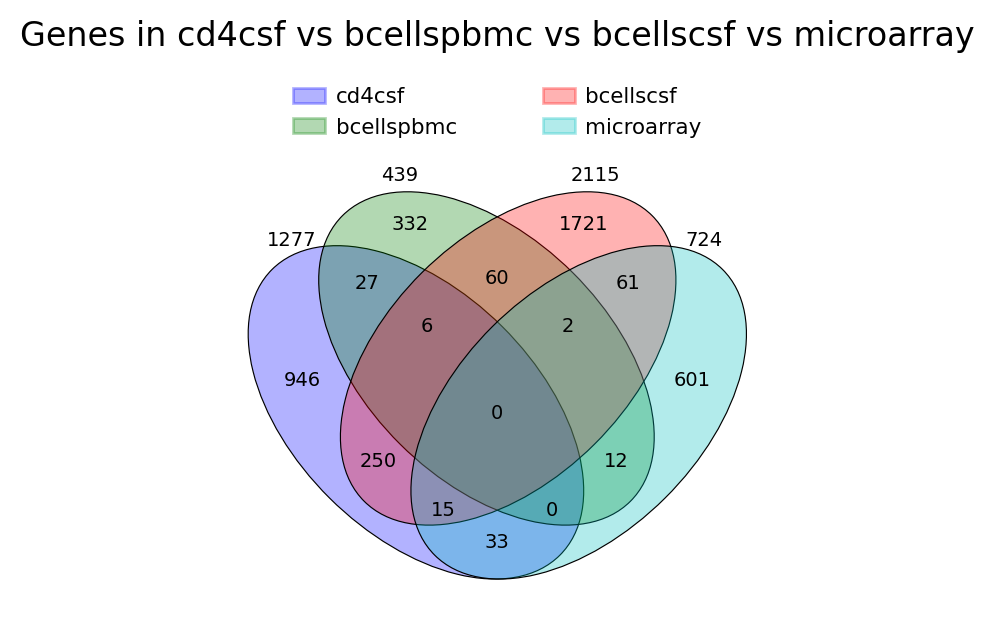

In [37]:
create_venn_diagram(
    [expl_cluster_cd4_csf_cutoff, expl_cluster_bcells_pbmc_cutoff,expl_cluster_bcells_csf_cutoff,expl_cluster_microarray_cutoff],
    labels=["cd4csf", "bcellspbmc", "bcellscsf", "microarray"],
    title="Genes in cd4csf vs bcellspbmc vs bcellscsf vs microarray",
)

In [16]:
microarray = set(expl_cluster_microarray.keys())
cd4csf = set(expl_cluster_cd4_csf.keys())
bcellspbmc = set(expl_cluster_bcells_pbmc.keys())
bcellscsf = set(expl_cluster_bcells_csf.keys())



In [17]:
intersection_all = microarray.intersection(cd4csf, bcellspbmc, bcellscsf)
intersection_all

{'DDOST', 'GMDS', 'SEC14L1'}

In [1]:
import networkx as nx

def read_graphml_to_networkx(file_path):
    """
    Reads a GraphML file into a NetworkX graph object.

    Args:
        file_path (str): The path to the GraphML file.

    Returns:
        networkx.Graph or networkx.DiGraph: A NetworkX graph object,
        or None if an error occurs.
    """
    try:
        graph = nx.read_graphml(file_path)
        print(f"Successfully loaded graph from '{file_path}'")
        return graph
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return None
    except Exception as e:
        print(f"An error occurred while reading the GraphML file: {e}")
        return None
    
    
graph = read_graphml_to_networkx("merge.graphml")

Successfully loaded graph from 'merge.graphml'


In [2]:
graph

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
def plot_graph_with_attributes(graph):
    """
    Plots a NetworkX graph with advanced visual attributes.

    - Filters out nodes with no 'network' attribute.
    - Represents multi-network nodes as multi-color pie charts.
    - Uses a shell layout based on 'network_count'.
    - Hides labels for nodes with a 'network_count' of 1.
    - CORRECTED: Now properly handles nested list data in the 'network' attribute.

    Args:
        graph (networkx.Graph or networkx.DiGraph): The graph to plot.
    """
    print("\n--- Starting plot_graph_with_attributes function ---")
    if not isinstance(graph, (nx.Graph, nx.DiGraph)) or not graph:
        print("Invalid or empty graph provided.")
        return

    # --- 1. Filter graph ---
    print("\nStep 1: Filtering graph...")
    graph_to_plot = graph.copy()
    nodes_to_remove = [
        node
        for node, data in graph_to_plot.nodes(data=True)
        if not data.get("network")
    ]
    if nodes_to_remove:
        graph_to_plot.remove_nodes_from(nodes_to_remove)
    print(
        f"  Graph filtered. {graph_to_plot.number_of_nodes()} nodes remain."
    )

    # --- 2. Extract attributes and build color map ---
    print("\nStep 2: Extracting attributes and preparing visual properties...")
    node_labels = {}
    node_sizes = {}
    all_individual_networks = set()

    for node_id, data in graph_to_plot.nodes(data=True):
        node_labels[node_id] = data.get("display name", str(node_id))
        count = data.get("network_count", 1)
        node_sizes[node_id] = 150 if count == 1 else max(200, 150 + count * 250)

        network_val = data.get("network", [])

        # --- FIX #1: FLATTEN NESTED LIST FOR COLOR MAPPING ---
        if (
            network_val
            and isinstance(network_val, list)
            and len(network_val) > 0
            and isinstance(network_val[0], list)
        ):
            network_val = network_val[0]
        # --- END FIX #1 ---

        if not isinstance(network_val, list):
            network_val = [network_val]
        for network_name in network_val:
            all_individual_networks.add(str(network_name))

    print(
        f"  Found {len(all_individual_networks)} unique individual networks."
    )
    sorted_networks = sorted(list(all_individual_networks))
    num_unique_networks = len(sorted_networks)
    cmap_name = "tab20" if num_unique_networks <= 20 else "rainbow"
    cmap = plt.colormaps[cmap_name]
    network_to_color_map = {
        net: cmap(i / max(1, num_unique_networks - 1))
        for i, net in enumerate(sorted_networks)
    }
    print("  Network to color map created for individual networks.")

    # --- 3. Calculate Graph Layout ---
    print("\nStep 3: Calculating graph layout...")
    shell_outer, shell_middle, shell_center = [], [], []
    for node_id, data in graph_to_plot.nodes(data=True):
        count = data.get("network_count", 1)
        if count == 1:
            shell_outer.append(node_id)
        elif count == 2:
            shell_middle.append(node_id)
        else:
            shell_center.append(node_id)
    shells = [
        shell
        for shell in [shell_center, shell_middle, shell_outer]
        if shell
    ]
    pos = nx.shell_layout(graph_to_plot, nlist=shells)
    print("  Shell layout calculated.")

    # --- 4. Plotting ---
    print("\nStep 4: Plotting the graph...")
    fig, ax = plt.subplots(figsize=(20, 16))
    plt.title(
        "Graph Visualization (Shells by count, Color by network)", size=18
    )
    ax.axis("off")

    print("  Drawing edges...")
    nx.draw_networkx_edges(
        graph_to_plot, pos, ax=ax, alpha=0.5, edge_color="gray"
    )

    print("  Drawing nodes (as circles or pie charts)...")
    for node_id, data in graph_to_plot.nodes(data=True):
        xy = pos[node_id]
        node_area = node_sizes[node_id]
        # The radius for the wedge needs to be scaled relative to the axes
        # This is an empirical value and might need adjustment
        radius = np.sqrt(node_area) / 1500.0

        networks = data.get("network", [])
        
        # --- FIX #2: FLATTEN NESTED LIST FOR PIE CHART LOGIC ---
        if (
            networks
            and isinstance(networks, list)
            and len(networks) > 0
            and isinstance(networks[0], list)
        ):
            networks = networks[0]
        # --- END FIX #2 ---

        if not isinstance(networks, list):
            networks = [networks]

        if len(networks) <= 1:
            color = (
                network_to_color_map.get(str(networks[0]), "gray")
                if networks
                else "gray"
            )
            ax.scatter(
                xy[0],
                xy[1],
                s=node_area,
                color=color,
                alpha=0.95,
                edgecolors="black",
                linewidths=0.5,
                zorder=2,
            )
        else:
            colors = [
                network_to_color_map.get(str(n), "gray") for n in networks
            ]
            num_wedges = len(colors)
            angle_per_wedge = 360.0 / num_wedges
            theta_start = 90
            for i in range(num_wedges):
                wedge = plt.Wedge(
                    center=xy,
                    r=radius,
                    theta1=theta_start,
                    theta2=theta_start + angle_per_wedge,
                    color=colors[i],
                    alpha=0.95,
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=2,
                )
                ax.add_patch(wedge)
                theta_start += angle_per_wedge

    print("  Drawing node labels...")
    for node_id, data in graph_to_plot.nodes(data=True):
        count = data.get("network_count", 1)
        if count > 2:
            font_size = 8 if count < 5 else 9
            x, y = pos[node_id]
            label = node_labels[node_id]
            ax.text(
                x,
                y,
                label,
                fontsize=font_size,
                fontweight="bold",
                ha="center",
                va="center",
                zorder=5,
            )

    print("  Creating custom legend...")
    legend_elements = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=f"Network: {net}",
            markerfacecolor=color,
            markersize=10,
        )
        for net, color in sorted(network_to_color_map.items())
    ]
    ax.legend(
        handles=legend_elements,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()
    print("--- Finished plot_graph_with_attributes function ---")

In [ ]:
plot_graph_with_attributes(graph)


--- Starting plot_graph_with_attributes function ---

Step 1: Filtering graph...
  Graph filtered. 3610 nodes remain.

Step 2: Extracting attributes and preparing visual properties...
  Found 14 unique individual networks.
  Network to color map created for individual networks.

Step 3: Calculating graph layout...
  Shell layout calculated.

Step 4: Plotting the graph...
  Drawing edges...
  Drawing nodes (as circles or pie charts)...
  Drawing node labels...
  Creating custom legend...


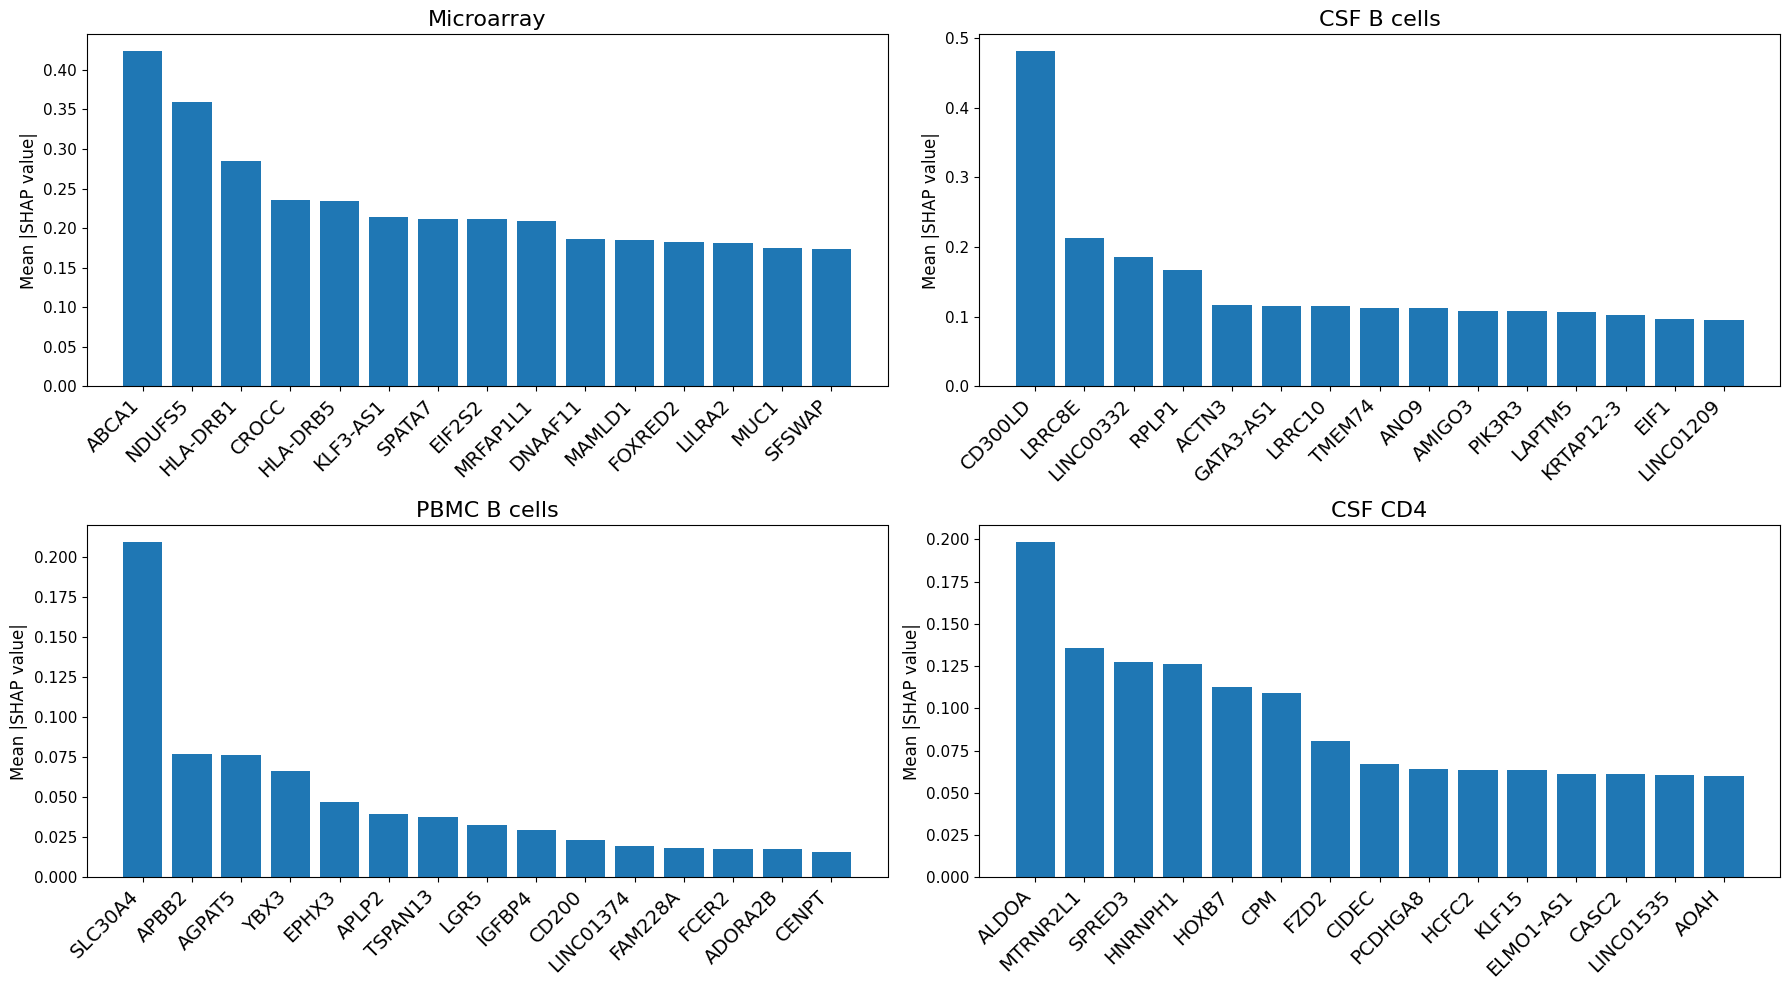

In [13]:

import matplotlib.pyplot as plt

cd4_csf_dir = "../Store/CD4_CSF_SAMU"
expl_cd4_csf = joblib.load(f'{cd4_csf_dir}/xgbCSFBCELLS_feature_importance.pkl')
pbmc_bcells_dir = "../Store/PBMC_BCELLS_2DATASET"
expl_bcells_pbmc = joblib.load(f'{pbmc_bcells_dir}/xgbPBMCBCELLS_feature_importance.pkl')
csf_bcells_dir = "../Store/CSF_BCELLS"
expl_bcells_csf = joblib.load(f'{csf_bcells_dir}/xgbCSFBCELLS2_feature_importance.pkl')
csf_bcells_dir = "../Store/MICROARRAY"
expl_microarray = joblib.load(f'{csf_bcells_dir}/xgbDefFull_explSorted.pkl')
expl_microarray = pd.DataFrame(expl_microarray.items(), columns=['Feature', 'MeanAbsoluteShap'])

# Prepare the list of explanation DataFrames
explanation_dfs = [
    expl_microarray,
    expl_bcells_csf,
    expl_bcells_pbmc,
    expl_cd4_csf
]

titles = [
    "Microarray",
    "CSF B cells",
    "PBMC B cells",
    "CSF CD4"
]


plt.figure(figsize=(18, 10))  # Wider than tall — much more compact

for i, (df, title) in enumerate(zip(explanation_dfs, titles), 1):
    plt.subplot(2, 2, i)
    shap_values = df['MeanAbsoluteShap'][:15].values   # top 15 to avoid clutter
    features = df['Feature'][:15].values

    plt.bar(features, shap_values)
    plt.ylabel("Mean |SHAP value|", fontsize=12)
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=14)
    plt.yticks(fontsize=11)
    plt.tight_layout()

plt.savefig("shapSUMMARY_4datasets.png")
plt.show()


In [ ]:
microarray_shapObject = joblib.load("../../SYMBOL/Results/DatasetFull/xgbDefFull_shapValues.pkl")
microarray = pd.read_csv("../../SYMBOL/Dataset/MergedDatasetFullCombatDeclustered_symbol.csv")
labels = microarray['Label']
labels = ['MS' if value == 1 else 'Control' for value in labels]
microarray.drop(columns=['SampleID', 'PatientID', 'Label'], inplace=True)

feature = 'ABCA1'
n_bins = 8  # o quantili
range_bins = pd.qcut(microarray[feature], q=n_bins)
bins = range_bins.apply(lambda x: f"[{x.left:.2f} – {x.right:.2f}]")

df_plot = pd.DataFrame({
    'shap_value': microarray_shapObject.values[:, microarray.columns.get_loc(feature)],
    'expression_bin': bins,
    'condition': labels
})

# Imposta i colori per le condizioni
palette = {'Control': 'lightblue', 'MS': 'lightcoral'}

# Crea il plot
plt.figure(figsize=(8, 8))
sns.boxplot(
    x='expression_bin',
    y='shap_value',
    hue='condition',
    data=df_plot,
    palette=palette,
    flierprops=dict(marker='o', color='black', markersize=6),
    boxprops=dict(edgecolor='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    notch=True
)

plt.title(f'SHAP values for {feature} by expression bin and condition')
plt.xlabel('Expression Bin')
plt.ylabel('SHAP Value')
plt.legend(title='Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()